# Predicting SLA Breaches at Ticket Creation: An Exploratory Analysis of ITSM Incidents

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv(r'C:\Users\Vishnu Ravi\python files\IT ticket data analysis project\incident_event_log.csv')
pd.set_option('display.max_columns', None)

## Problem Definition

**What is being predicted?**
Binary classification: SLA breach (made_sla == False)

**When is the prediction made?**
At ticket creation

**Why does it matter?**
Prioritization, staffing, escalation

**Real-world usage:**
This model could be used to flag high-risk tickets for early intervention.

Answer explicitly:

What is being predicted?
Binary classification: SLA breach (made_sla == False)

When is the prediction made?
At ticket creation

Why does it matter?
Prioritization, staffing, escalation

**Include a 1-paragraph “real-world usage”:**

“This model could be used to flag high-risk tickets for early intervention.”

## 2. Data Understanding and Granularity

## 2.1 Dataset Overview

This analysis uses the IT Incident Event Log dataset, a publicly available dataset commonly used to study service desk operations and SLA performance. The raw data contains 119,998 rows and 36 columns, representing logged events associated with IT incident tickets.

Each incident is identified by a unique number (20,769 distinct incidents). Rather than being incident-level, the dataset is event-level, meaning that each row corresponds to a logged update or state change for an incident over its lifecycle.

Key implications of this structure:

A single incident (number) appears in multiple rows.

Certain attributes (e.g., incident_state, sys_mod_count, sys_updated_at) evolve over time.

Time-based fields such as resolved_at and closed_at may appear populated even in early lifecycle rows due to system backfilling behavior.

Understanding and properly handling this granularity is critical to avoid incorrect aggregation, double-counting, or temporal data leakage.

In [2]:

df = pd.read_csv("incident_event_log.csv")

# Basic shape and structure
print("Raw dataset shape:", df.shape)
n_incidents = df['number'].nunique()
print(f"number of incidents: {n_incidents}")

print("Average rows per incident:", df.shape[0] / n_incidents)
# Preview data
df.head()




Raw dataset shape: (119998, 36)
number of incidents: 20769
Average rows per incident: 5.777745678655688


,number,incident_state,active,reassignment_count,reopen_count,sys_mod_count,made_sla,caller_id,opened_by,opened_at,sys_created_by,sys_created_at,sys_updated_by,sys_updated_at,contact_type,location,category,subcategory,u_symptom,cmdb_ci,impact,urgency,priority,assignment_group,assigned_to,knowledge,u_priority_confirmation,notify,problem_id,rfc,vendor,caused_by,closed_code,resolved_by,resolved_at,closed_at
0,INC0000045,New,True,0,0,0,True,Caller 2403,Opened by 8,29/2/2016 01:16,Created by 6,29/2/2016 01:23,Updated by 21,29/2/2016 01:23,Phone,Location 143,Category 55,Subcategory 170,Symptom 72,?,2 - Medium,2 - Medium,3 - Moderate,Group 56,?,True,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
1,INC0000045,Resolved,True,0,0,2,True,Caller 2403,Opened by 8,29/2/2016 01:16,Created by 6,29/2/2016 01:23,Updated by 642,29/2/2016 08:53,Phone,Location 143,Category 55,Subcategory 170,Symptom 72,?,2 - Medium,2 - Medium,3 - Moderate,Group 56,?,True,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
2,INC0000045,Resolved,True,0,0,3,True,Caller 2403,Opened by 8,29/2/2016 01:16,Created by 6,29/2/2016 01:23,Updated by 804,29/2/2016 11:29,Phone,Location 143,Category 55,Subcategory 170,Symptom 72,?,2 - Medium,2 - Medium,3 - Moderate,Group 56,?,True,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
3,INC0000045,Closed,False,0,0,4,True,Caller 2403,Opened by 8,29/2/2016 01:16,Created by 6,29/2/2016 01:23,Updated by 908,5/3/2016 12:00,Phone,Location 143,Category 55,Subcategory 170,Symptom 72,?,2 - Medium,2 - Medium,3 - Moderate,Group 56,?,True,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
4,INC0000047,New,True,0,0,0,True,Caller 2403,Opened by 397,29/2/2016 04:40,Created by 171,29/2/2016 04:57,Updated by 746,29/2/2016 04:57,Phone,Location 165,Category 40,Subcategory 215,Symptom 471,?,2 - Medium,2 - Medium,3 - Moderate,Group 70,Resolver 89,True,False,Do Not Notify,?,?,?,?,code 5,Resolved by 81,1/3/2016 09:52,6/3/2016 10:00


2.2 Event-Level vs. Incident-Level Structure

An inspection of the data confirms that:

Multiple rows correspond to the same incident number.

Rows represent chronological events, not independent observations.

Incident lifecycle information is spread across multiple records.

Because the modeling goal is to predict whether an incident will miss its SLA, the appropriate unit of analysis for prediction is the incident, not the event. Therefore, all downstream analysis and modeling must be performed at the incident level, with exactly one row per incident.

To support this, the dataset will later be aggregated such that:

Each incident is represented by a single record.

Features are derived from information available at a clearly defined point in time.

The target variable (made_sla) is uniquely defined per incident.


In [3]:
# Count how many rows each incident appears in
incident_event_counts = df['number'].value_counts()

incident_event_counts.describe()
# Inspect incidents with multiple lifecycle events
incident_event_counts.head(5)
# Show an example of a single incident across multiple rows
example_incident = incident_event_counts.index[1]
df[df['number'] == example_incident].head(5)


,number,incident_state,active,reassignment_count,reopen_count,sys_mod_count,made_sla,caller_id,opened_by,opened_at,sys_created_by,sys_created_at,sys_updated_by,sys_updated_at,contact_type,location,category,subcategory,u_symptom,cmdb_ci,impact,urgency,priority,assignment_group,assigned_to,knowledge,u_priority_confirmation,notify,problem_id,rfc,vendor,caused_by,closed_code,resolved_by,resolved_at,closed_at
26389,INC0005927,New,True,0,0,0,True,Caller 1173,Opened by 301,11/3/2016 11:25,?,?,Updated by 908,11/3/2016 11:25,Phone,Location 81,Category 51,Subcategory 301,Symptom 592,?,2 - Medium,2 - Medium,3 - Moderate,Group 54,?,False,False,Do Not Notify,?,?,?,?,code 6,Resolved by 15,29/4/2016 09:37,4/5/2016 10:07
26390,INC0005927,New,True,0,0,1,True,Caller 1173,Opened by 301,11/3/2016 11:25,?,?,Updated by 874,11/3/2016 12:00,Phone,Location 81,Category 51,Subcategory 301,Symptom 592,?,2 - Medium,2 - Medium,3 - Moderate,Group 54,?,False,False,Do Not Notify,?,?,?,?,code 6,Resolved by 15,29/4/2016 09:37,4/5/2016 10:07
26391,INC0005927,New,True,1,0,2,True,Caller 1173,Opened by 301,11/3/2016 11:25,?,?,Updated by 874,11/3/2016 12:00,Phone,Location 81,Category 51,Subcategory 301,Symptom 592,?,2 - Medium,2 - Medium,3 - Moderate,Group 70,?,False,False,Do Not Notify,?,?,?,?,code 6,Resolved by 15,29/4/2016 09:37,4/5/2016 10:07
26392,INC0005927,New,True,2,0,5,True,Caller 1173,Opened by 301,11/3/2016 11:25,?,?,Updated by 915,11/3/2016 13:57,Phone,Location 81,Category 51,Subcategory 301,Symptom 592,?,2 - Medium,2 - Medium,3 - Moderate,Group 54,?,False,False,Do Not Notify,?,?,?,?,code 6,Resolved by 15,29/4/2016 09:37,4/5/2016 10:07
26393,INC0005927,New,True,2,0,6,True,Caller 1173,Opened by 301,11/3/2016 11:25,?,?,Updated by 874,11/3/2016 16:24,Phone,Location 81,Category 51,Subcategory 301,Symptom 592,?,2 - Medium,2 - Medium,3 - Moderate,Group 54,?,False,False,Do Not Notify,?,?,?,?,code 6,Resolved by 15,29/4/2016 09:37,4/5/2016 10:07


2.3 Prediction Timing and Feature Availability

The prediction task is framed as a classification problem: predicting whether an incident will miss its SLA (made_sla = False) at the time the ticket is created.

This framing imposes an important constraint:

Only information available at or before ticket creation may be used for exploratory analysis and modeling.

As a result:

Post-creation attributes (e.g., resolved_at, closed_at, sys_mod_count, reassignment counts, and later incident_state transitions) must be excluded from predictive feature analysis.

These post-hoc variables may still be useful for operational or descriptive analysis, but not for predictive modeling.

This distinction ensures that any insights or models developed reflect a realistic deployment scenario and avoids temporal data leakage.
It seems that opened_at does not change and merely represents the initial time that the incident is opened

In [4]:
# Show how temporal columns change over the course of the same incident
temporal_columns = [
    'number',
    'incident_state',
    'sys_mod_count',
    'sys_created_at',
    'sys_updated_at',
    'opened_at',
    'resolved_at',
    'closed_at',
    'assigned_to',
    'assignment_group'
]

df[df['number'] == example_incident][temporal_columns].head(10)



,number,incident_state,sys_mod_count,sys_created_at,sys_updated_at,opened_at,resolved_at,closed_at,assigned_to,assignment_group
26389,INC0005927,New,0,?,11/3/2016 11:25,11/3/2016 11:25,29/4/2016 09:37,4/5/2016 10:07,?,Group 54
26390,INC0005927,New,1,?,11/3/2016 12:00,11/3/2016 11:25,29/4/2016 09:37,4/5/2016 10:07,?,Group 54
26391,INC0005927,New,2,?,11/3/2016 12:00,11/3/2016 11:25,29/4/2016 09:37,4/5/2016 10:07,?,Group 70
26392,INC0005927,New,5,?,11/3/2016 13:57,11/3/2016 11:25,29/4/2016 09:37,4/5/2016 10:07,?,Group 54
26393,INC0005927,New,6,?,11/3/2016 16:24,11/3/2016 11:25,29/4/2016 09:37,4/5/2016 10:07,?,Group 54
26394,INC0005927,New,7,?,11/3/2016 16:24,11/3/2016 11:25,29/4/2016 09:37,4/5/2016 10:07,?,Group 70
26395,INC0005927,New,8,?,11/3/2016 17:45,11/3/2016 11:25,29/4/2016 09:37,4/5/2016 10:07,?,Group 58
26396,INC0005927,New,9,?,14/3/2016 07:50,11/3/2016 11:25,29/4/2016 09:37,4/5/2016 10:07,?,Group 70
26397,INC0005927,New,10,?,14/3/2016 08:20,11/3/2016 11:25,29/4/2016 09:37,4/5/2016 10:07,?,Group 76
26398,INC0005927,New,12,?,17/3/2016 10:51,11/3/2016 11:25,29/4/2016 09:37,4/5/2016 10:07,?,Group 69


In [5]:
# Show how incident_state evolves within a single incident
df[df['number'] == example_incident][
    ['number', 'incident_state', 'sys_mod_count', 'sys_updated_at']
].head(10)

,number,incident_state,sys_mod_count,sys_updated_at
26389,INC0005927,New,0,11/3/2016 11:25
26390,INC0005927,New,1,11/3/2016 12:00
26391,INC0005927,New,2,11/3/2016 12:00
26392,INC0005927,New,5,11/3/2016 13:57
26393,INC0005927,New,6,11/3/2016 16:24
26394,INC0005927,New,7,11/3/2016 16:24
26395,INC0005927,New,8,11/3/2016 17:45
26396,INC0005927,New,9,14/3/2016 07:50
26397,INC0005927,New,10,14/3/2016 08:20
26398,INC0005927,New,12,17/3/2016 10:51


2.4 Missing Values and Logging Behavior

Several attributes in the dataset use the string '?' to represent unknown or unrecorded values. According to the dataset documentation, these should be treated as missing information, not literal values.

Additionally, some fields (particularly time-based fields such as resolved_at) are populated retroactively by the system, meaning their presence in early lifecycle rows does not imply that the information was known at that time.

These behaviors further reinforce the need for:

Explicit missing value normalization during preprocessing.

Careful consideration of feature availability relative to prediction timing.

Incident-level aggregation before modeling.

In [6]:
# Count occurrences of '?' per column
question_mark_counts = (df == '?').sum().sort_values(ascending=False)

# Percentage of '?' values per column
(question_mark_counts / len(df)).sort_values(ascending=False).head(15)


caused_by           0.999850
vendor              0.998483
cmdb_ci             0.996367
rfc                 0.992650
problem_id          0.983858
sys_created_at      0.352956
sys_created_by      0.352956
u_symptom           0.235596
assigned_to         0.191920
assignment_group    0.118444
opened_by           0.040292
resolved_at         0.023842
closed_code         0.004375
resolved_by         0.001683
subcategory         0.000808
dtype: float64

In [7]:
# Show rows where incidents are still 'New' but resolved_at is populated
backfilled_time_example = df[
    (df['incident_state'] == 'New') &
    (df['resolved_at'] != '?')
][['number', 'incident_state', 'opened_at', 'resolved_at']]

backfilled_time_example.head(10)


,number,incident_state,opened_at,resolved_at
0,INC0000045,New,29/2/2016 01:16,29/2/2016 11:29
4,INC0000047,New,29/2/2016 04:40,1/3/2016 09:52
13,INC0000057,New,29/2/2016 06:10,1/3/2016 02:55
14,INC0000057,New,29/2/2016 06:10,1/3/2016 02:55
15,INC0000057,New,29/2/2016 06:10,1/3/2016 02:55
16,INC0000057,New,29/2/2016 06:10,1/3/2016 02:55
17,INC0000057,New,29/2/2016 06:10,1/3/2016 02:55
20,INC0000060,New,29/2/2016 06:38,2/3/2016 12:06
24,INC0000062,New,29/2/2016 06:58,29/2/2016 15:51
25,INC0000062,New,29/2/2016 06:58,29/2/2016 15:51


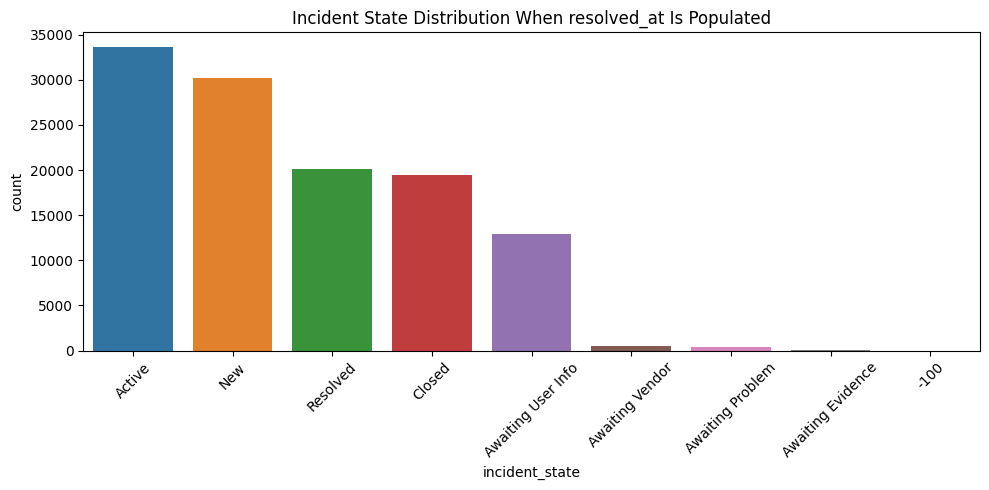

In [8]:
# Plot: distribution of incident_state where resolved_at is not missing
import seaborn as sns
import matplotlib.pyplot as plt

resolved_present = df[df['resolved_at'] != '?']

plt.figure(figsize=(10, 5))
sns.countplot(
    data=resolved_present,
    x='incident_state',
    order=resolved_present['incident_state'].value_counts().index
)
plt.title("Incident State Distribution When resolved_at Is Populated")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


2.5 Summary of Implications for Analysis

From this initial data understanding step, several key decisions follow:

The raw dataset cannot be modeled directly due to its event-level structure.

Incident-level aggregation is required prior to EDA and modeling.

Predictive analysis must be restricted to creation-time information.

Later lifecycle fields are excluded to prevent data leakage.

## 3. Data Cleaning and Normalization

Before performing any aggregation or exploratory analysis at the incident level, the raw event-level data must be cleaned and standardized. This section focuses exclusively on structural data cleaning, without performing feature selection, aggregation, or modeling preparation. The goal is to ensure consistency, interpretability, and correctness in later stages of analysis.

## 3.1 Standardizing Missing Values

Several attributes in the dataset use the string '?' to represent unknown or unrecorded information. According to the dataset documentation, these values indicate missing data rather than valid categorical levels.

To ensure consistent handling of missing values across numeric, categorical, and datetime fields, all occurrences of '?' are normalized to NaN. This allows missingness to be handled using standard pandas functionality and avoids ad hoc string-based checks later in the pipeline.

At this stage:

Missing values are standardized but not imputed

No assumptions are made about the underlying meaning of missingness

Decisions about imputation or exclusion are deferred to later sections

This separation ensures that cleaning does not prematurely bias downstream analysis.

In [9]:
# Normalize '?' placeholders to NaN across the entire dataframe
# According to the dataset documentation, '?' represents unknown information
df = df.replace('?', np.nan)

# Sanity check: count missing values per column (top 10)
df.isna().sum().sort_values(ascending=False).head(10)

caused_by           119980
vendor              119816
cmdb_ci             119562
rfc                 119116
problem_id          118061
sys_created_at       42354
sys_created_by       42354
u_symptom            28271
assigned_to          23030
assignment_group     14213
dtype: int64

## 3.2 Datetime Parsing and Temporal Consistency

The dataset contains multiple timestamp fields, including:

opened_at

sys_created_at

sys_updated_at

resolved_at

closed_at

All datetime columns are parsed into a consistent datetime format. This step is necessary even though some of these fields will later be excluded from predictive modeling, for several reasons:

Proper parsing allows validation of lifecycle ordering

Temporal consistency checks depend on comparable datetime formats

Feature extraction (e.g., hour or day of week) requires parsed timestamps

Backfilled timestamps can only be detected and reasoned about once parsed

It is important to note that some time-based fields (particularly resolved_at) are populated retroactively by the system. Their presence in early lifecycle rows does not imply that the information was known at that time. Parsing these fields enables later exclusion based on prediction timing rather than raw availability.

In [10]:
# List of known datetime columns in the dataset
datetime_cols = [
    'opened_at',
    'sys_created_at',
    'sys_updated_at',
    'resolved_at',
    'closed_at'
]

# Parse datetime columns using coercion to handle invalid formats
for col in datetime_cols:
    df[col + '_dt'] = pd.to_datetime(df[col], errors='coerce', dayfirst=True)

# Check how many values failed to parse per column
df[[col + '_dt' for col in datetime_cols]].isna().sum()


opened_at_dt             0
sys_created_at_dt    42354
sys_updated_at_dt        0
resolved_at_dt        2861
closed_at_dt             0
dtype: int64

## 3.3 Extraction of Basic Time-Based Attributes

From the ticket creation timestamp (opened_at), basic time-based attributes such as:

Hour of day

Day of week

are extracted.

These features are derived directly from information available at ticket creation and are therefore valid for both exploratory analysis and predictive modeling. They capture potential operational patterns (e.g., staffing levels, business hours) without introducing temporal leakage.

In [11]:
# Extract creation-time features from opened_at only
# These features are available at ticket creation and are safe for modeling
df['opened_hour'] = df['opened_at_dt'].dt.hour
df['opened_dayofweek'] = df['opened_at_dt'].dt.dayofweek

# Inspect extracted features
df[['opened_at_dt', 'opened_hour', 'opened_dayofweek']].head()


,opened_at_dt,opened_hour,opened_dayofweek
0,2016-02-29 01:16:00,1,0
1,2016-02-29 01:16:00,1,0
2,2016-02-29 01:16:00,1,0
3,2016-02-29 01:16:00,1,0
4,2016-02-29 04:40:00,4,0


## 3.4 Validation and Consistency Checks

Several lightweight validation checks are performed to ensure the dataset behaves as expected before aggregation:

Incident identifiers (number) are verified to be non-missing

Boolean fields (e.g., active, knowledge, u_priority_confirmation) are checked for consistency

Target variable consistency (made_sla) is inspected across rows belonging to the same incident to ensure it is well-defined at the incident level

Obvious structural anomalies (e.g., negative or illogical timestamp orderings) are flagged for later inspection

These checks are diagnostic rather than corrective. Any necessary filtering or correction is deferred until incident-level aggregation is performed.

In [12]:
# Verify that incident identifiers are never missing
df['number'].isna().value_counts()


number
False    119998
Name: count, dtype: int64

In [13]:
# Inspect boolean-like columns for unexpected values
boolean_cols = [
    'active',
    'knowledge',
    'u_priority_confirmation',
    'made_sla'
]

for col in boolean_cols:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts(dropna=False))



Value counts for active:
active
True     99172
False    20826
Name: count, dtype: int64

Value counts for knowledge:
knowledge
False    94664
True     25334
Name: count, dtype: int64

Value counts for u_priority_confirmation:
u_priority_confirmation
False    87564
True     32434
Name: count, dtype: int64

Value counts for made_sla:
made_sla
True     111738
False      8260
Name: count, dtype: int64


In [14]:
# Check whether made_sla is consistent across rows for the same incident
sla_consistency = df.groupby('number')['made_sla'].nunique()

# Report incidents where made_sla varies across lifecycle rows
inconsistent_sla = sla_consistency[sla_consistency > 1]

len(inconsistent_sla), "incidents have inconsistent made_sla values"



(8173, 'incidents have inconsistent made_sla values')

In [15]:
# Inspect a few inconsistent examples, if any exist
if len(inconsistent_sla) > 0:
    example_ids = inconsistent_sla.index[:5]
    df[df['number'].isin(example_ids)][['number', 'incident_state', 'made_sla']]

# since this code returns no output, we can conclude that made_sla is consistent across rows for the same incident

## 3.5 Scope and Deferred Decisions

At the conclusion of this section:

No rows or columns have been dropped

No aggregation has been performed

No modeling assumptions have been introduced

In [16]:
# Confirm no rows or columns were dropped during cleaning
df.shape


(119998, 43)

In [17]:
# Confirm that event-level structure is still intact
df['number'].nunique(), "unique incidents still represented across", len(df), "rows"


(20769, 'unique incidents still represented across', 119998, 'rows')

## 4. Incident-Level Aggregation and Target Definition

The raw dataset is event-level, with multiple rows corresponding to the same incident as it progresses through its lifecycle. Because the prediction task is to determine whether an incident will miss its SLA at the time of ticket creation, the data must be transformed to the incident level, with exactly one row per incident.

This section defines how incident-level records are constructed, how the target variable is determined, and which features are retained or excluded to preserve temporal validity.

## 4.1 Defining the Incident Creation Snapshot

For each incident (number), the creation-time snapshot is defined as the first recorded event by opened_at timestamp. This row represents the earliest available system record of the incident and serves as the reference point for all creation-time features.

Using the first opened_at event ensures that:

Features reflect information available at ticket creation

Later lifecycle updates do not leak post-creation information

Temporal ordering is consistent and reproducible

In [18]:
# Sort by opened_at_dt to ensure deterministic ordering
# Note: per dataset behavior, opened_at is consistent within each incident
df_sorted = df.sort_values('opened_at_dt')

# Select the first row per incident as the creation snapshot
creation_snapshot = (
    df_sorted
    .groupby('number', as_index=False)
    .first()
)

print("Creation snapshot shape:", creation_snapshot.shape)
print("Unique incidents:", creation_snapshot['number'].nunique())


Creation snapshot shape: (20769, 43)
Unique incidents: 20769


## 4.2 Incident Inclusion Criteria

Only closed incidents are included in the incident-level dataset used for modeling. Since SLA outcomes can only be evaluated once an incident is resolved, unresolved incidents are excluded from training and evaluation.

However, unresolved incidents are explicitly flagged during aggregation. This allows them to be:

   - Analyzed descriptively

   - Potentially scored by a trained model in a real-world deployment scenario

In [19]:
# Flag unresolved incidents
creation_snapshot['is_closed'] = creation_snapshot['incident_state'].str.lower() == 'closed'

# Set made_sla to NaN for unresolved incidents
creation_snapshot.loc[~creation_snapshot['is_closed'], 'made_sla'] = np.nan

# Inspect counts
creation_snapshot['is_closed'].value_counts(dropna=False)


is_closed
False    13065
True      7704
Name: count, dtype: int64

In [ ]:

creation_snapshot.loc[
    ~creation_snapshot['is_closed'],
    'made_sla'
].value_counts(dropna=False)


made_sla
NaN    13065
Name: count, dtype: int64

## 4.3 Target Variable Definition

The target variable for modeling is made_sla, a binary indicator of whether the incident met its SLA.

Based on validation performed during data cleaning:

-made_sla is assumed to be constant across all lifecycle events for a given incident

-The incident-level target is therefore defined directly from the validated event-level value

-No additional transformation of the target variable is required

In [21]:
# Verify that made_sla was consistent per incident prior to aggregation
sla_variation = df.groupby('number')['made_sla'].nunique()

inconsistent_incidents = sla_variation[sla_variation > 1]

print("Incidents with inconsistent made_sla values:", len(inconsistent_incidents))


Incidents with inconsistent made_sla values: 8173


In [ ]:

if len(inconsistent_incidents) > 0:
    example_ids = inconsistent_incidents.index[:5]
    df[df['number'].isin(example_ids)][['number', 'incident_state', 'made_sla']]


## 4.4 Aggregation Strategy

A hybrid aggregation strategy is used to construct the incident-level dataset:

Creation-time features
Features available at ticket creation are taken directly from the creation snapshot row (e.g., category, priority, contact type, location, creation time attributes).

Simple lifecycle aggregates
Selected operational attributes that summarize early lifecycle behavior (e.g., counts of updates or reassignments) may be aggregated at the incident level. These aggregates are carefully chosen and implemented in code to avoid temporal leakage.

This hybrid approach preserves both the predictive value of creation-time information and high-level operational signals, while maintaining a clear temporal boundary.

In [ ]:

early_lifecycle = df[df['incident_state'].str.lower() != 'closed']

print("Early lifecycle rows:", early_lifecycle.shape[0])


Early lifecycle rows: 99173


In [ ]:

incident_aggregates = (
    early_lifecycle
    .groupby('number')
    .agg(
        num_updates=('number', 'count'),
        total_sys_mod_count=('sys_mod_count', 'max'),
        num_reassignments=('reassignment_count', 'max'),
        num_reopens=('reopen_count', 'max')
    )
    .reset_index()
)

incident_aggregates.head()


,number,num_updates,total_sys_mod_count,num_reassignments,num_reopens
0,INC0000045,3,3,0,0
1,INC0000047,8,7,1,0
2,INC0000057,6,5,0,0
3,INC0000060,3,2,0,0
4,INC0000062,7,6,1,0


## 4.5 Feature Inclusion and Exclusion

After aggregation, the incident-level dataset includes:

Included features

-Creation-time categorical attributes (e.g., category, subcategory, priority, contact_type)

-Creation-time temporal features (e.g., hour of day, day of week)

-Selected operational aggregates implemented with temporal safeguards

Excluded features (due to leakage risk)

-Post-resolution timestamps (resolved_at, closed_at)

-Full lifecycle state transitions (incident_state)

-Any attributes that directly encode or imply resolution outcomes

Explicitly separating included and excluded features ensures that the resulting dataset reflects a realistic prediction scenario and avoids inadvertently learning from future information.

In [25]:
# Merge creation snapshot with aggregates
incident_level_df = creation_snapshot.merge(
    incident_aggregates,
    on='number',
    how='left'
)

print("Incident-level dataset shape:", incident_level_df.shape)


Incident-level dataset shape: (20769, 48)


In [26]:
# Explicitly drop known leaky columns
leaky_columns = [
    'resolved_at', 'resolved_at_dt',
    'closed_at', 'closed_at_dt',
    'incident_state'
]

incident_level_df = incident_level_df.drop(
    columns=[col for col in leaky_columns if col in incident_level_df.columns]
)

print("Columns after leakage control:", incident_level_df.shape[1])


Columns after leakage control: 43


## 4.6 Output of Aggregation

The output of this section is a single incident-level table with:

-Exactly one row per incident

-A clearly defined binary target (made_sla)

-Features aligned with the prediction timing constraint

This dataset forms the basis for:

-Incident-level exploratory analysis (Section 5)

-Baseline modeling and advanced models such as XGBoost (Section 6)

By resolving the event-versus-incident mismatch at this stage, all subsequent analysis and modeling steps are grounded in a consistent and defensible data representation.

In [27]:
# One row per incident
incident_level_df['number'].nunique(), len(incident_level_df)


(20769, 20769)

In [28]:
# Target distribution (closed incidents only)
incident_level_df.loc[
    incident_level_df['is_closed'],
    'made_sla'
].value_counts(normalize=True, dropna=False)


made_sla
True     0.576713
False    0.423287
Name: proportion, dtype: float64

In [29]:
# Inspect final dataset
incident_level_df.head()


,number,active,reassignment_count,reopen_count,sys_mod_count,made_sla,caller_id,opened_by,opened_at,sys_created_by,sys_created_at,sys_updated_by,sys_updated_at,contact_type,location,category,subcategory,u_symptom,cmdb_ci,impact,urgency,priority,assignment_group,assigned_to,knowledge,u_priority_confirmation,notify,problem_id,rfc,vendor,caused_by,closed_code,resolved_by,opened_at_dt,sys_created_at_dt,sys_updated_at_dt,opened_hour,opened_dayofweek,is_closed,num_updates,total_sys_mod_count,num_reassignments,num_reopens
0,INC0000045,True,0,0,0,NaN,Caller 2403,Opened by 8,29/2/2016 01:16,Created by 6,29/2/2016 01:23,Updated by 21,29/2/2016 01:23,Phone,Location 143,Category 55,Subcategory 170,Symptom 72,None,2 - Medium,2 - Medium,3 - Moderate,Group 56,None,True,False,Do Not Notify,None,None,None,None,code 5,Resolved by 149,2016-02-29 01:16:00,2016-02-29 01:23:00,2016-02-29 01:23:00,1,0,False,3,3,0,0
1,INC0000047,True,0,0,0,NaN,Caller 2403,Opened by 397,29/2/2016 04:40,Created by 171,29/2/2016 04:57,Updated by 746,29/2/2016 04:57,Phone,Location 165,Category 40,Subcategory 215,Symptom 471,None,2 - Medium,2 - Medium,3 - Moderate,Group 70,Resolver 89,True,False,Do Not Notify,None,None,None,None,code 5,Resolved by 81,2016-02-29 04:40:00,2016-02-29 04:57:00,2016-02-29 04:57:00,4,0,False,8,7,1,0
2,INC0000057,False,0,0,6,True,Caller 4416,Opened by 8,29/2/2016 06:10,None,None,Updated by 908,6/3/2016 03:00,Phone,Location 204,Category 20,Subcategory 125,Symptom 471,None,2 - Medium,2 - Medium,3 - Moderate,Group 70,Resolver 6,True,False,Do Not Notify,Problem ID 2,None,None,None,code 10,Resolved by 5,2016-02-29 06:10:00,NaT,2016-03-06 03:00:00,6,0,True,6,5,0,0
3,INC0000060,True,0,0,0,NaN,Caller 4491,Opened by 180,29/2/2016 06:38,Created by 81,29/2/2016 06:42,Updated by 340,29/2/2016 06:42,Phone,Location 204,Category 9,Subcategory 97,Symptom 450,None,2 - Medium,2 - Medium,3 - Moderate,Group 25,Resolver 125,True,False,Do Not Notify,None,None,None,None,code 3,Resolved by 113,2016-02-29 06:38:00,2016-02-29 06:42:00,2016-02-29 06:42:00,6,0,False,3,2,0,0
4,INC0000062,True,1,0,5,NaN,Caller 3765,Opened by 180,29/2/2016 06:58,Created by 81,29/2/2016 07:26,Updated by 241,29/2/2016 15:51,Phone,Location 93,Category 53,Subcategory 168,Symptom 232,None,1 - High,2 - Medium,2 - High,Group 23,None,True,False,Do Not Notify,None,None,None,None,code 7,Resolved by 62,2016-02-29 06:58:00,2016-02-29 07:26:00,2016-02-29 15:51:00,6,0,False,7,6,1,0
